# Data exploration (images only, without lables)

## Dataset overview for PNG image folder
Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.

===== DATASET OVERVIEW =====
Dataset location: C:\Users\Tobi\Downloads\karolina-oc\test-images\test-images
Number of samples (images): 500

Typical image dimensions:
{'width': 256, 'height': 256}
Approx. number of features per image: 65536

Color modes:
mode
L    500
Name: count, dtype: int64

First rows of dataset structure:


,filename,width,height,channels,mode,estimated_features
0,0.png,256,256,1,L,65536
1,1.png,256,256,1,L,65536
2,10.png,256,256,1,L,65536
3,100.png,256,256,1,L,65536
4,101.png,256,256,1,L,65536


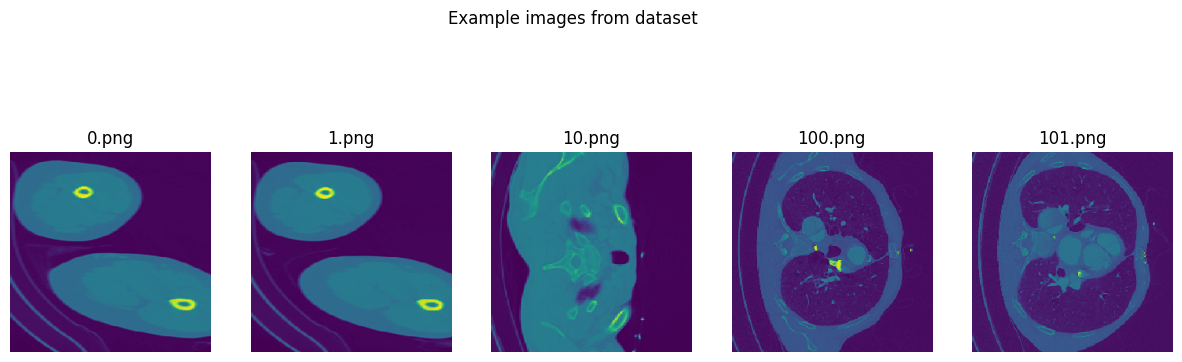

In [ ]:
import os
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Dataset path (relative to notebook location)
# ----------------------------------------------------
dataset_path = Path("test-images/test-images")

# Collect PNG files
image_files = list(dataset_path.glob("*.png"))

# ----------------------------------------------------
# Basic statistics
# ----------------------------------------------------
num_samples = len(image_files)

info = []

for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            mode = img.mode      # RGB, RGBA, L, etc.

            info.append({
                "filename": img_path.name,
                "width": width,
                "height": height,
                "channels": len(img.getbands()),
                "mode": mode
            })

    except Exception as e:
        print(f"Could not load {img_path}: {e}")

df = pd.DataFrame(info)

# Estimate "features"
# Features = width × height × channels
if not df.empty:
    df["estimated_features"] = (
        df["width"] *
        df["height"] *
        df["channels"]
    )

# ----------------------------------------------------
# Print dataset overview
# ----------------------------------------------------
print("===== DATASET OVERVIEW =====")
print(f"Dataset location: {dataset_path.resolve()}")
print(f"Number of samples (images): {num_samples}")

if not df.empty:
    print("\nTypical image dimensions:")
    print(df[["width", "height"]].mode().iloc[0].to_dict())

    print(
        "Approx. number of features per image:",
        int(df["estimated_features"].median())
    )

    print("\nColor modes:")
    print(df["mode"].value_counts())

print("\nFirst rows of dataset structure:")
display(df.head())

# ----------------------------------------------------
# Show example images
# ----------------------------------------------------
n_examples = min(5, num_samples)

fig, axes = plt.subplots(1, n_examples, figsize=(15,5))

if n_examples == 1:
    axes = [axes]

for ax, img_path in zip(axes, image_files[:n_examples]):
    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(img_path.name[:15])
    ax.axis("off")

plt.suptitle("Example images from dataset")
plt.show()

## Handling Missing Values

Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.

In [2]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError
import pandas as pd

# Path to dataset
dataset_path = Path("data/test-images/test-images")

image_files = list(dataset_path.glob("*.png"))

missing_or_corrupt = []
valid_images = []

for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            img.verify()  # checks if image is corrupted

        # Re-open (verify() closes file)
        with Image.open(img_path) as img:
            width, height = img.size

        valid_images.append(img_path.name)

    except (UnidentifiedImageError, OSError, SyntaxError) as e:
        missing_or_corrupt.append(img_path.name)

# -----------------------------
# Summary
# -----------------------------
print("===== MISSING / CORRUPT DATA CHECK =====")
print(f"Total images found: {len(image_files)}")
print(f"Valid images: {len(valid_images)}")
print(f"Corrupt/unreadable images: {len(missing_or_corrupt)}")

if missing_or_corrupt:
    print("\nExamples of problematic files:")
    print(missing_or_corrupt[:10])
else:
    print("\nNo missing or corrupt images found.")

===== MISSING / CORRUPT DATA CHECK =====
Total images found: 500
Valid images: 500
Corrupt/unreadable images: 0

No missing or corrupt images found.


## Feature Distributions
Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.

In [3]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dataset_path = Path("data/test-images/test-images")
image_files = list(dataset_path.glob("*.png"))

data = []

for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            channels = len(img.getbands())
            
            data.append({
                "width": width,
                "height": height,
                "aspect_ratio": width / height,
                "channels": channels
            })
    except:
        continue

df = pd.DataFrame(data)

print("===== FEATURE SUMMARY =====")
display(df.describe())

===== FEATURE SUMMARY =====


,width,height,aspect_ratio,channels
count,500.0,500.0,500.0,500.0
mean,256.0,256.0,1.0,1.0
std,0.0,0.0,0.0,0.0
min,256.0,256.0,1.0,1.0
25%,256.0,256.0,1.0,1.0
50%,256.0,256.0,1.0,1.0
75%,256.0,256.0,1.0,1.0
max,256.0,256.0,1.0,1.0


### Verify grayscale structure

In [4]:
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd

dataset_path = Path("data/test-images/test-images")
image_files = list(dataset_path.glob("*.png"))

info = []

for img_path in image_files:
    with Image.open(img_path) as img:
        mode = img.mode  # 'L' = grayscale
        
        arr = np.array(img)
        
        info.append({
            "filename": img_path.name,
            "mode": mode,
            "mean_intensity": arr.mean(),
            "std_intensity": arr.std(),
            "min_intensity": arr.min(),
            "max_intensity": arr.max()
        })

df = pd.DataFrame(info)

print("===== IMAGE COLOR MODE CHECK =====")
print(df["mode"].value_counts())
display(df.head())

===== IMAGE COLOR MODE CHECK =====
mode
L    500
Name: count, dtype: int64


,filename,mode,mean_intensity,std_intensity,min_intensity,max_intensity
0,0.png,L,60.064301,46.733900,12,255
1,1.png,L,57.369705,46.726438,12,255
2,10.png,L,69.231445,49.470957,12,255
3,100.png,L,33.170456,29.463355,2,255
4,101.png,L,35.643387,30.062309,0,255


All images are stored in grayscale format (mode = ‘L’), meaning each pixel represents intensity values ranging from black (0) to white (255). No RGB channels are present.

 ### Distribution of Greytones (Intensity Statistics) Image vs. Image

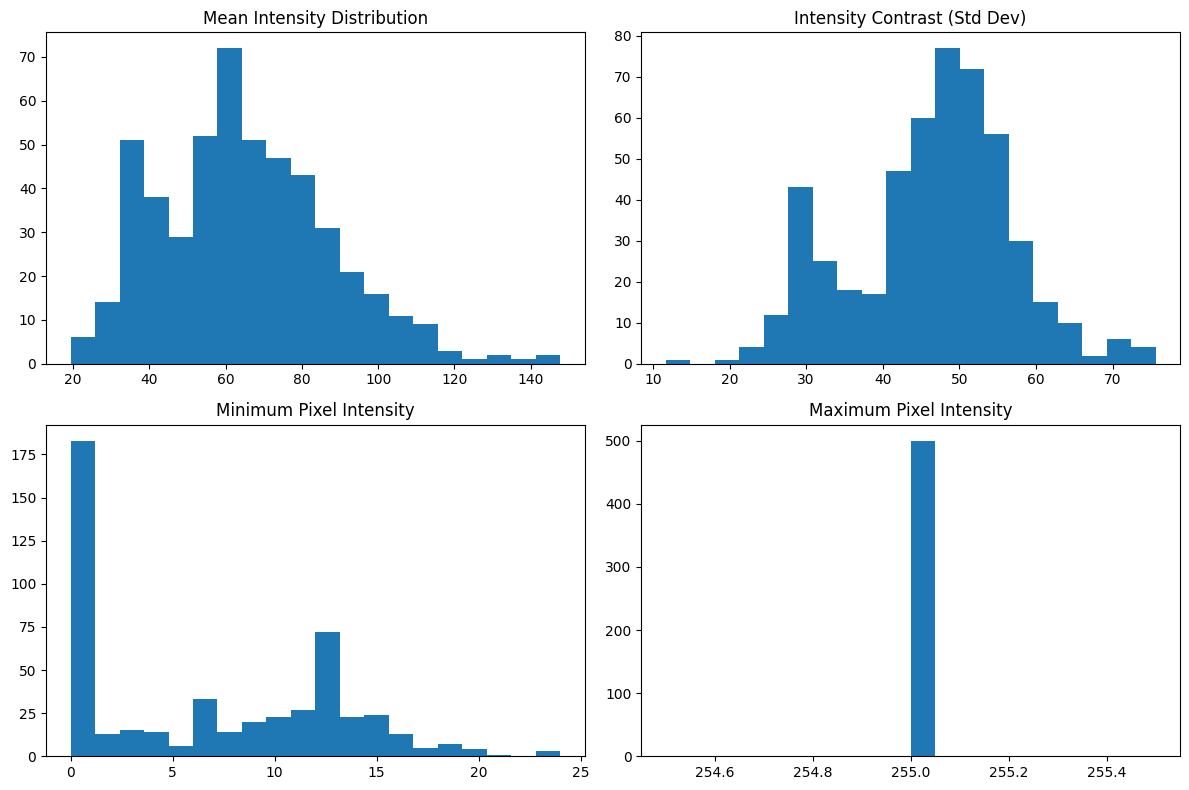

In [5]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Mean intensity distribution
axs[0, 0].hist(df["mean_intensity"], bins=20)
axs[0, 0].set_title("Mean Intensity Distribution")

# Standard deviation (contrast)
axs[0, 1].hist(df["std_intensity"], bins=20)
axs[0, 1].set_title("Intensity Contrast (Std Dev)")

# Min intensity
axs[1, 0].hist(df["min_intensity"], bins=20)
axs[1, 0].set_title("Minimum Pixel Intensity")

# Max intensity
axs[1, 1].hist(df["max_intensity"], bins=20)
axs[1, 1].set_title("Maximum Pixel Intensity")

plt.tight_layout()
plt.show()

1. Brightness distribution
peak near 0 → dark dataset
peak near 255 → bright dataset
centered peak → balanced lighting

The dataset shows a strong concentration around low-intensity values, which is expected due to the nature of CT scans.

2. Contrast (std deviation)
low std → flat / low-contrast images
high std → strong edges / detailed structure

A wide spread in standard deviation suggests varying levels of contrast across images.

3. Outliers
Look for:
extremely bright or dark images
near-constant images (std ≈ 0)

Example:
“A few images exhibit unusually low variance, indicating nearly uniform intensity regions.”

### Brightness vs contrast per image
- dark + low contrast images
- bright + high contrast images
- clusters/outliers

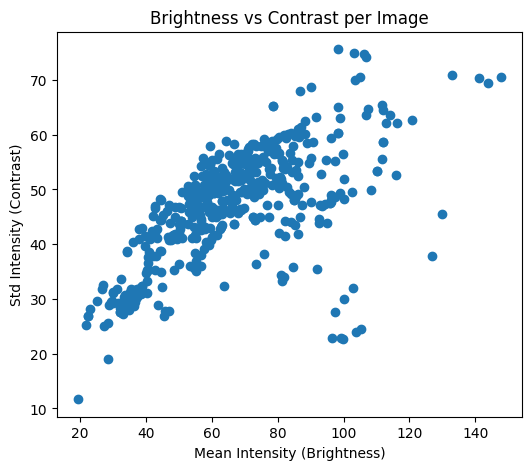

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(df["mean_intensity"], df["std_intensity"])
plt.xlabel("Mean Intensity (Brightness)")
plt.ylabel("Std Intensity (Contrast)")
plt.title("Brightness vs Contrast per Image")
plt.show()

### Global Grey Tone Distribution (All Pixels)

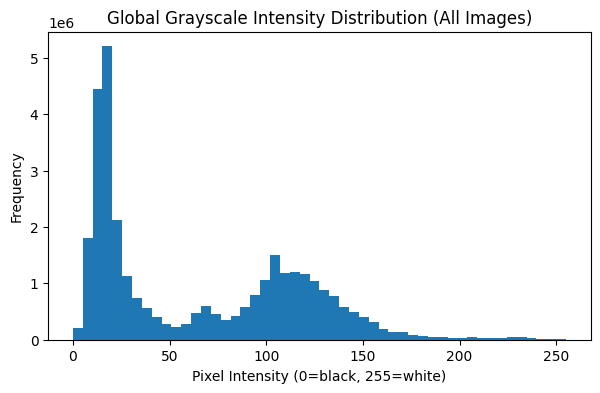

In [7]:
all_pixels = []

for img_path in image_files:
    with Image.open(img_path) as img:
        arr = np.array(img)
        all_pixels.append(arr.ravel())

all_pixels = np.concatenate(all_pixels)

plt.figure(figsize=(7,4))
plt.hist(all_pixels, bins=50)
plt.title("Global Grayscale Intensity Distribution (All Images)")
plt.xlabel("Pixel Intensity (0=black, 255=white)")
plt.ylabel("Frequency")
plt.show()

This shows the actual grayscale “shape” of the dataset.

## Possible Biases
Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).

Since the dataset consists of CT images, potential biases were investigated through image-level statistics including intensity distribution, resolution variance, and clustering behavior. No explicit labels or demographic metadata were available; therefore, bias analysis focused on acquisition-related variability.

In CT imaging, bias usually comes from:

- Class imbalance (if labels exist)
e.g. “healthy vs diseased”
one class dominates → model becomes biased
- Scanner / hospital bias (VERY common in CT)
different machines produce different:
intensity distributions
noise levels
resolutions
- Patient demographic bias (if metadata exists)
age, gender, etc.
- Acquisition bias
slice thickness differences
contrast vs non-contrast CT
different protocols
- Technical bias (image-level)
resolution differences
brightness/contrast shifts
artifacts (motion, noise)

### Image-level distribution bias

In [8]:
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

dataset_path = Path("data/test-images/test-images")
image_files = list(dataset_path.glob("*.png"))

rows = []

for img_path in image_files:
    with Image.open(img_path) as img:
        arr = np.array(img)

        rows.append({
            "file": img_path.name,
            "width": img.size[0],
            "height": img.size[1],
            "mean_intensity": arr.mean(),
            "std_intensity": arr.std()
        })

df = pd.DataFrame(rows)

df.describe()

,width,height,mean_intensity,std_intensity
count,500.0,500.0,500.000000,500.000000
mean,256.0,256.0,65.026209,46.392687
std,0.0,0.0,22.407192,10.518760
min,256.0,256.0,19.385788,11.687027
25%,256.0,256.0,49.260666,40.869571
50%,256.0,256.0,62.985451,48.055489
75%,256.0,256.0,79.845875,53.189780
max,256.0,256.0,147.718948,75.602705


- large spread in width/height → resizing bias needed
- multi-modal intensity distribution → scanner bias
- high std variation → inconsistent imaging conditions

### Detect “scanner-style clusters” (hidden bias)

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = df[["mean_intensity", "std_intensity", "width", "height"]]

X = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

df["cluster"].value_counts()

cluster
2    253
1    134
0    113
Name: count, dtype: int64

If clusters form:
- Cluster 1 = dark low-contrast CTs
- Cluster 2 = bright high-noise CTs
- Cluster 3 = high-res scans
This indicates hidden acquisition bias

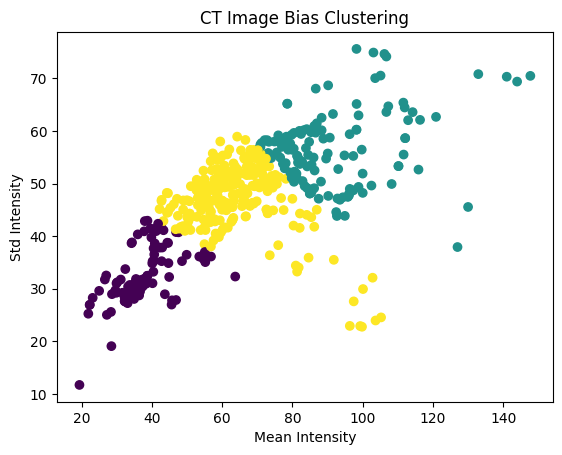

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["mean_intensity"], df["std_intensity"], c=df["cluster"])
plt.xlabel("Mean Intensity")
plt.ylabel("Std Intensity")
plt.title("CT Image Bias Clustering")
plt.show()

- If clusters are separated → dataset **is not** homogeneous
- If one cluster dominates → strong bias toward one acquisition style

## Correlations
Explore correlations between features and the target variable, as well as among features themselves.

### Feature–Feature Correlation
This checks relationships like brightness vs contrast, resolution vs intensity, etc.

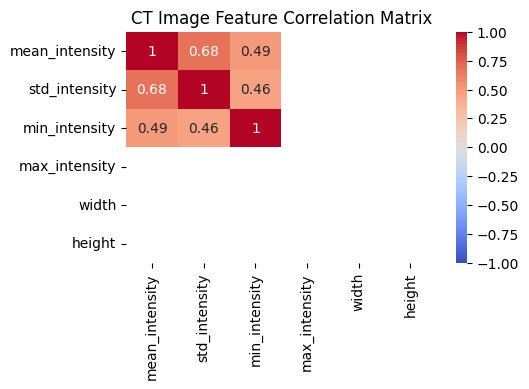

,filename,mean_intensity,std_intensity,min_intensity,max_intensity,width,height
0,0.png,60.064301,46.733900,12,255,256,256
1,1.png,57.369705,46.726438,12,255,256,256
2,10.png,69.231445,49.470957,12,255,256,256
3,100.png,33.170456,29.463355,2,255,256,256
4,101.png,35.643387,30.062309,0,255,256,256


In [16]:
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
dataset_path = Path("data/test-images/test-images")
image_files = list(dataset_path.glob("*.png"))

# -----------------------------
# Extract features safely
# -----------------------------
rows = []

for img_path in image_files:
    with Image.open(img_path) as img:
        arr = np.array(img)

        rows.append({
            "filename": img_path.name,
            "mean_intensity": arr.mean(),
            "std_intensity": arr.std(),
            "min_intensity": arr.min(),
            "max_intensity": arr.max(),
            "width": img.size[0],
            "height": img.size[1]
        })

df = pd.DataFrame(rows)

# -----------------------------
# Correlation matrix (safe)
# -----------------------------
corr_df = df[[
    "mean_intensity",
    "std_intensity",
    "min_intensity",
    "max_intensity",
    "width",
    "height"
]]

corr_matrix = corr_df.corr()

# -----------------------------
# Plot heatmap
# -----------------------------
plt.figure(figsize=(5,3))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("CT Image Feature Correlation Matrix")
plt.show()

# -----------------------------
# Optional: show dataframe preview
# -----------------------------
display(df.head())

Look for:

- **Strong positive correlation (+1)**
width ↔ height → images scaled together
min ↔ max → consistent intensity range
- **Weak correlation (~0)**
intensity vs size → independent properties
- **Strong negative correlation (-1)**
rare in image metadata, but possible if preprocessing is inconsistent

“The correlation matrix shows relationships between intensity-based and structural features. Weak correlations suggest that brightness and resolution are independent properties of the dataset, while strong correlations between width and height indicate consistent image scaling.”

# Data exploration (images with lables)

## Load and inspect annotated_labels.json

You now have three label states per organ per image:
- Explicitly present in annotated_labels.json → organ is definitely present
- Explicitly marked absent → organ is definitely NOT present
- Missing from JSON → unknown (unlabeled) OR could be present OR absent

In [23]:
import json
from pathlib import Path

json_path = Path("data/annotated_labels.json")

with open(json_path, "r") as f:
    annotations = json.load(f)

print("Number of scans:", len(annotations))

Number of scans: 2000


In [25]:
import json

with open("data/annotated_labels.json", "r") as f:
    annotations = json.load(f)

print(type(annotations))
print(annotations[:2])

<class 'list'>
[[2, 4, 8, 10, 11, 12, 13, 14, 15, 18, 20, 22, 23, 24, 28, 30, 31, 32, 36, 44, 46, 47, 49, 50, 52, 53, 54], [4, 6, 10, 11, 12, 13, 15, 17, 19, 21, 23, 24, 25, 26, 27, 29, 33, 37, 42, 45, 46, 47, 48, 49, 51, 53, 54]]


### Convert into dataframe

In [30]:
print("TYPE:", type(annotations))
print("FIRST ITEM TYPE:", type(annotations[0]))
print("FIRST ITEM VALUE:\n", annotations[0])

TYPE: <class 'list'>
FIRST ITEM TYPE: <class 'list'>
FIRST ITEM VALUE:
 [2, 4, 8, 10, 11, 12, 13, 14, 15, 18, 20, 22, 23, 24, 28, 30, 31, 32, 36, 44, 46, 47, 49, 50, 52, 53, 54]
